# Credit Card Fraud Detection — EDA & Modeling

Dataset: [Kaggle — Credit Card Fraud Detection (ULB)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

284,807 transactions made by European cardholders in September 2013, over
two days. Only **492 (0.173%)** are fraudulent — this is a severe class
imbalance problem, and the modeling approach below is built around that
fact rather than around it.

Features `V1`-`V28` are the result of a PCA transformation (original
features aren't published for confidentiality). `Time` and `Amount` are
the only two features not transformed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load & inspect the data

In [2]:
df = pd.read_csv("../data/creditcard.csv")
df.shape

(284807, 31)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.isnull().sum().sum()  # 0 -> no missing values in this dataset

np.int64(0)

## 2. Class imbalance

This is the single most important fact about this dataset, and it drives
every modeling decision below.

Legit: 284,315  Fraud: 492  (0.173% fraud)


/tmp/ipykernel_670/1474230279.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Legit", "Fraud"])


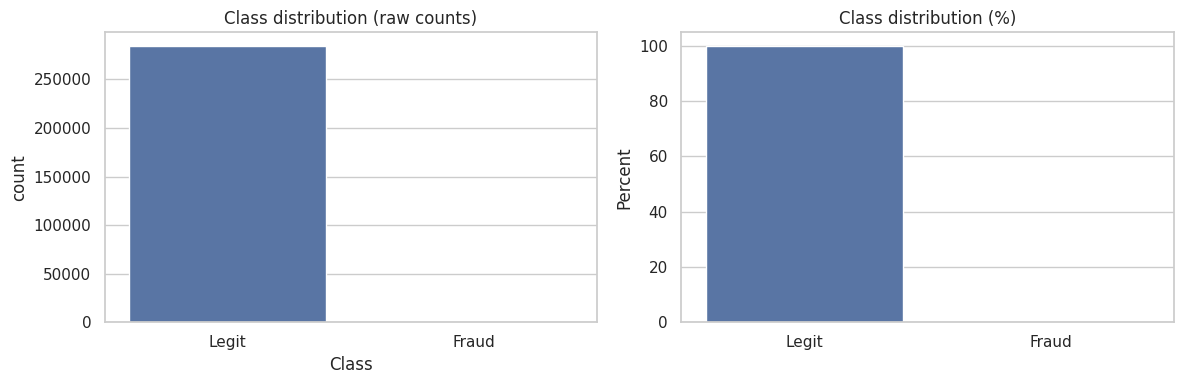

In [6]:
class_counts = df["Class"].value_counts()
fraud_pct = df["Class"].mean() * 100
print(f"Legit: {class_counts[0]:,}  Fraud: {class_counts[1]:,}  ({fraud_pct:.3f}% fraud)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Class", data=df, ax=ax[0])
ax[0].set_title("Class distribution (raw counts)")
ax[0].set_xticklabels(["Legit", "Fraud"])

sns.barplot(x=["Legit", "Fraud"], y=[100 - fraud_pct, fraud_pct], ax=ax[1])
ax[1].set_title("Class distribution (%)")
ax[1].set_ylabel("Percent")
plt.tight_layout()
plt.show()

**Implication:** a model that predicts "legit" for every transaction would
score 99.8% accuracy while catching zero fraud. Accuracy is therefore not
a usable metric here — precision, recall, F1, ROC-AUC and especially
**PR-AUC** (average precision) are used instead throughout this notebook.

## 3. Amount & Time by class

/tmp/ipykernel_670/3686236391.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Legit", "Fraud"])


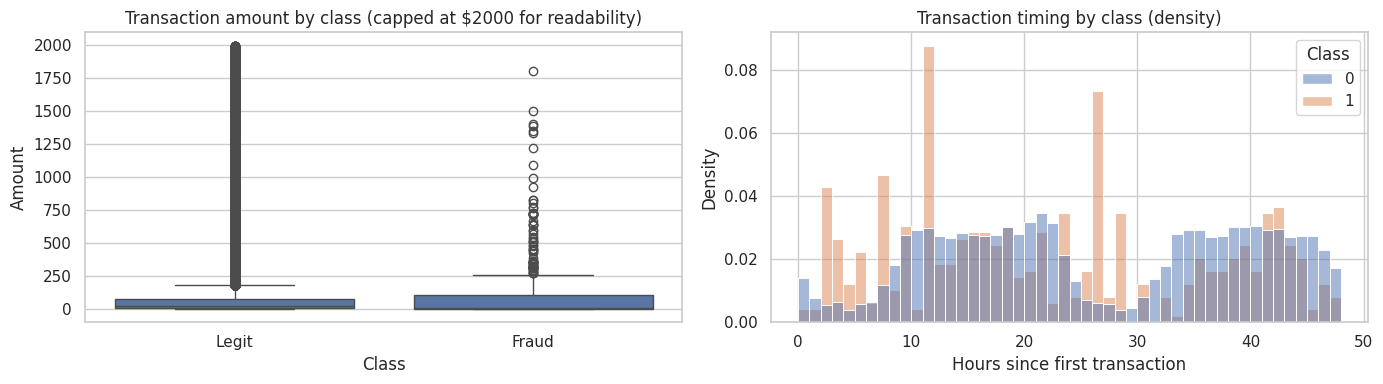

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x="Class", y="Amount", data=df[df.Amount < 2000], ax=ax[0])
ax[0].set_xticklabels(["Legit", "Fraud"])
ax[0].set_title("Transaction amount by class (capped at $2000 for readability)")

time_df = pd.DataFrame({"hours": df["Time"] / 3600, "Class": df["Class"]})
sns.histplot(data=time_df, x="hours", hue="Class", bins=48, stat="density", common_norm=False, ax=ax[1])
ax[1].set_xlabel("Hours since first transaction")
ax[1].set_title("Transaction timing by class (density)")
plt.tight_layout()
plt.show()

In [8]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Fraudulent transactions tend to have a different amount distribution than
legitimate ones, but there's meaningful overlap — no single feature
separates the classes cleanly, which is why the PCA components (V1-V28)
matter and a multivariate model is needed.

## 4. Correlation of V1-V28 with the target

Since V1-V28 are PCA components, checking which ones correlate most with
`Class` gives a quick read on which "directions" in the data separate
fraud from legitimate activity — useful context before modeling, and a
sanity check against the feature-importance plot at the end.

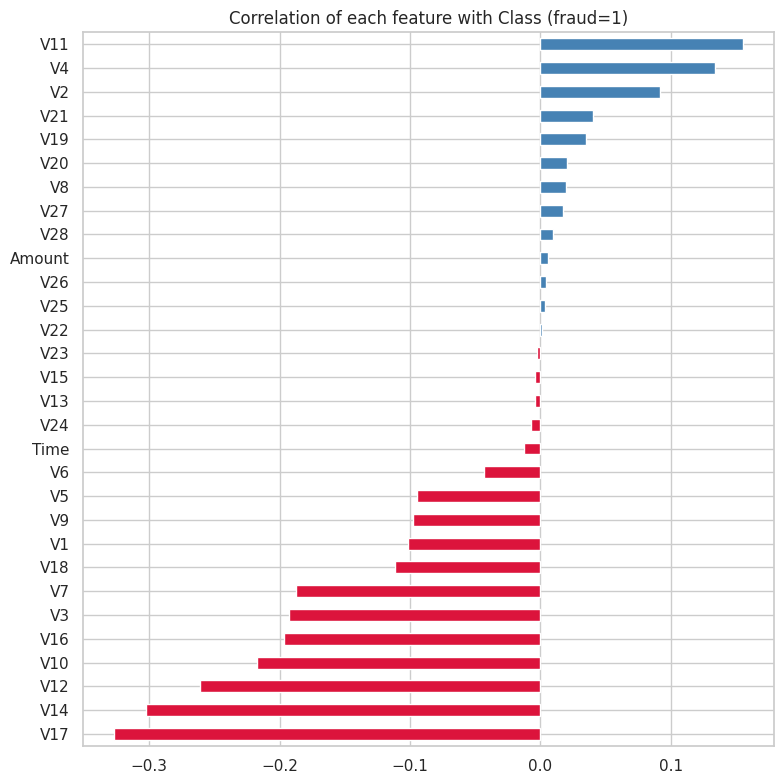

In [9]:
corr = df.corr()["Class"].drop("Class").sort_values()
plt.figure(figsize=(8, 8))
corr.plot(kind="barh", color=["crimson" if v < 0 else "steelblue" for v in corr])
plt.title("Correlation of each feature with Class (fraud=1)")
plt.tight_layout()
plt.show()

## 5. Feature scaling

`V1`-`V28` are already PCA components on a comparable scale. `Time` and
`Amount` are raw and need scaling for the linear model (Logistic
Regression) to treat all features fairly.

In [10]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[["Time", "Amount"]] = scaler.fit_transform(df_scaled[["Time", "Amount"]])

X = df_scaled.drop(columns="Class")
y = df_scaled["Class"]

## 6. Train/test split — BEFORE any resampling

This is the most important methodology choice in this notebook. The
original repo's approach undersampled the *entire* dataset down to
984 rows (492 legit + 492 fraud) before splitting into train/test —
meaning the reported metrics were measured on an artificial 50/50 test
set that never occurs in production, where fraud is 0.17% of traffic.

Here, the split happens first, and only the **training** fold gets
resampled. The test set keeps the real-world imbalanced distribution,
so every metric below reflects how the model would actually perform.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, fraud rate {y_train.mean()*100:.3f}%")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean()*100:.3f}%  <- untouched, realistic")

Train: (227845, 30), fraud rate 0.173%
Test:  (56962, 30), fraud rate 0.172%  <- untouched, realistic


In [12]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE (training data only):", y_train_smote.value_counts().to_dict())

After SMOTE (training data only): {0: 227451, 1: 227451}


## 7. Train & compare models

Four models, each handling the imbalance differently:

| Model | Imbalance strategy |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Decision Tree | trained on SMOTE-resampled data |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight` |

All four are evaluated on the same untouched, imbalanced test set.

In [13]:
results = []
fitted_models = {}


def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }
    results.append(metrics)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))
    return y_pred, y_proba

In [14]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
evaluate("Logistic Regression (class_weight)", lr, X_test, y_test)
fitted_models["Logistic Regression"] = lr


Logistic Regression (class_weight)
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [15]:
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_train_smote, y_train_smote)
evaluate("Decision Tree (SMOTE)", dt, X_test, y_test)
fitted_models["Decision Tree"] = dt


Decision Tree (SMOTE)
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.05      0.83      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.90      0.54     56962
weighted avg       1.00      0.97      0.99     56962



In [16]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
evaluate("Random Forest (class_weight)", rf, X_test, y_test)
fitted_models["Random Forest"] = rf


Random Forest (class_weight)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train, y_train)
evaluate("XGBoost (scale_pos_weight)", xgb, X_test, y_test)
fitted_models["XGBoost"] = xgb


XGBoost (scale_pos_weight)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## 8. Results comparison

Sorted by **PR-AUC** (average precision), the standard metric for rare-event
detection — much more informative than accuracy when the positive class is
0.17% of the data.

In [18]:
results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
display_df = results_df.copy()
for col in ["precision", "recall", "f1", "roc_auc", "pr_auc"]:
    display_df[col] = (display_df[col] * 100).round(2)
display_df

,model,precision,recall,f1,roc_auc,pr_auc
3,XGBoost (scale_pos_weight),87.23,83.67,85.42,97.75,87.60
2,Random Forest (class_weight),84.21,81.63,82.90,97.47,82.91
0,Logistic Regression (class_weight),6.09,91.84,11.41,97.22,71.89
1,Decision Tree (SMOTE),5.30,82.65,9.97,88.50,45.12


## 9. Confusion matrices & PR/ROC curves

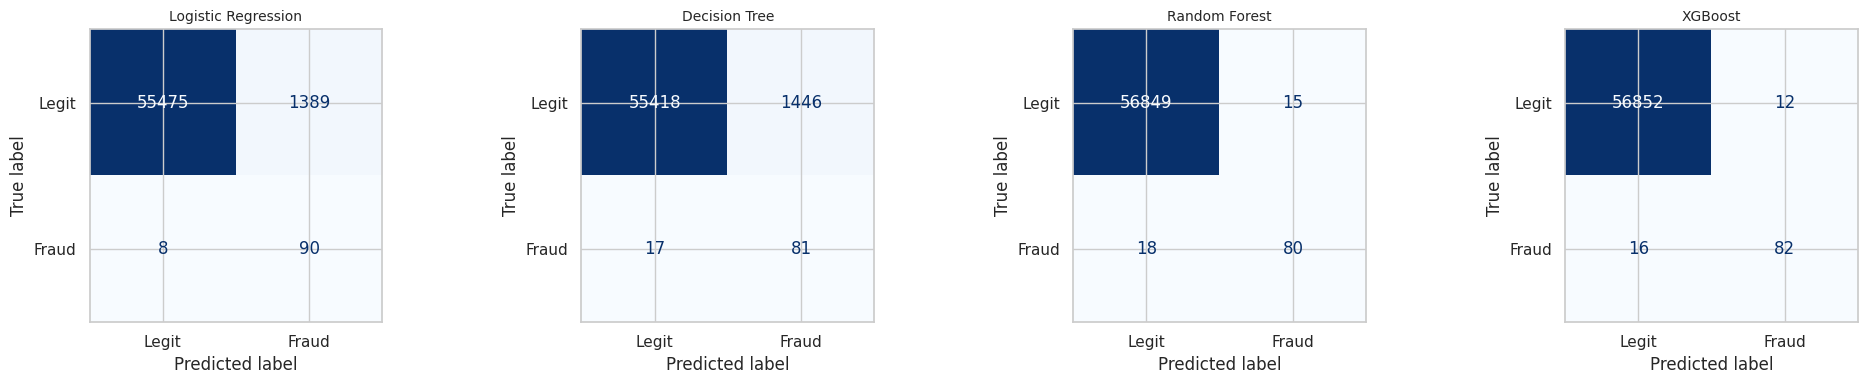

In [19]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(5 * len(fitted_models), 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

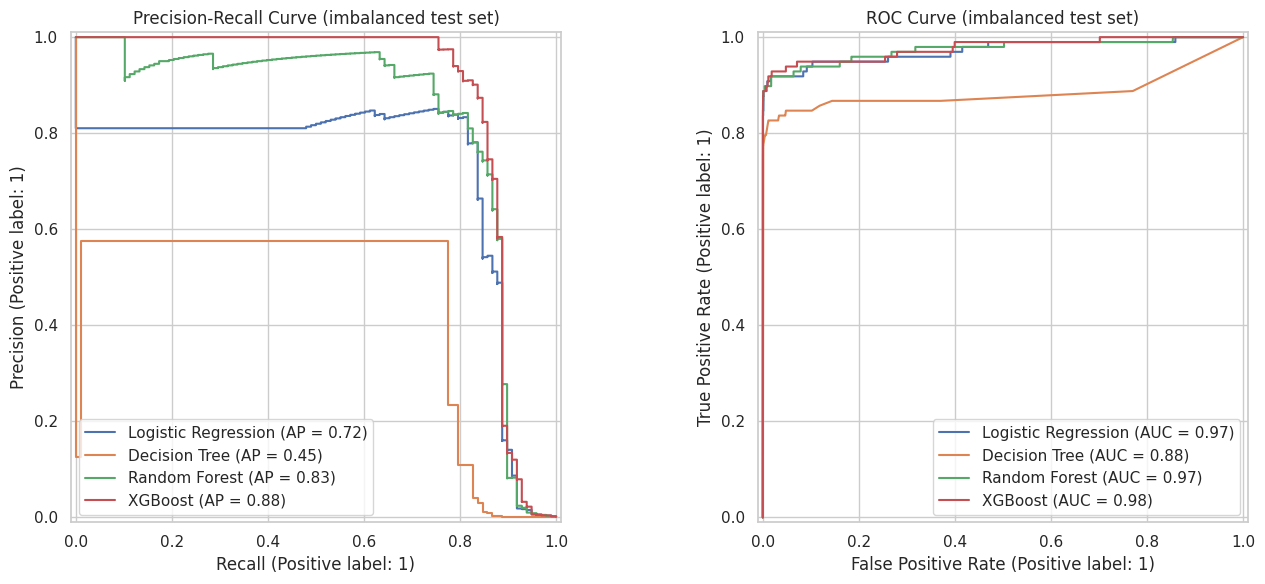

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1])
axes[0].set_title("Precision-Recall Curve (imbalanced test set)")
axes[1].set_title("ROC Curve (imbalanced test set)")
plt.tight_layout()
plt.show()

## 10. Cross-validation sanity check

A single train/test split can be lucky or unlucky, especially with only
~98 fraud cases in the test fold. 5-fold stratified cross-validation on
the best model checks that the result is stable.

In [21]:
best_name = results_df.iloc[0]["model"]
best_key = [k for k in fitted_models if k in best_name][0]
best_model = fitted_models[best_key]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if best_key == "Decision Tree":
    cv_scores = cross_val_score(
        DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
        X_train_smote, y_train_smote, cv=cv, scoring="average_precision", n_jobs=-1,
    )
else:
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)

print(f"Best model: {best_name}")
print(f"5-fold CV PR-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Best model: XGBoost (scale_pos_weight)
5-fold CV PR-AUC: 0.8476 (+/- 0.0186)


## 11. Feature importance (best model)

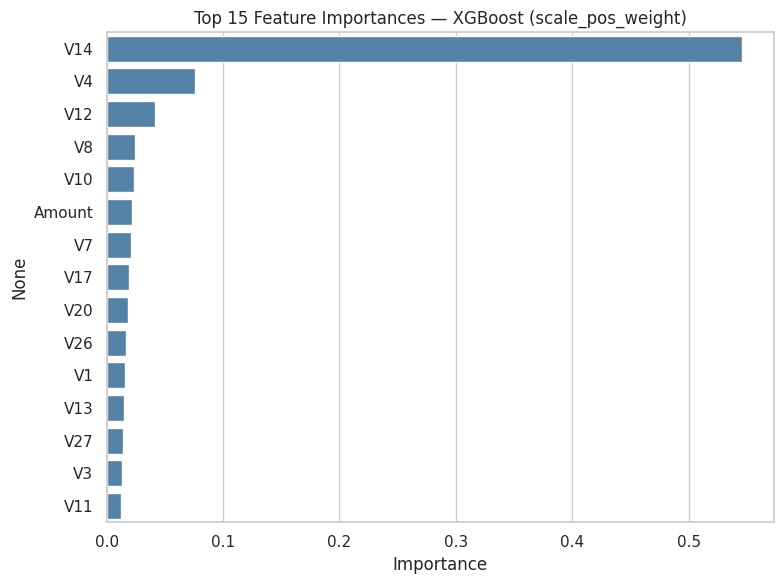

In [22]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, color="steelblue")
    plt.title(f"Top 15 Feature Importances — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 12. Save the best model for deployment

The saved model, scaler, and feature list power `src/predict.py` and the
Streamlit app in `app/app.py`.

In [23]:
import json

import joblib

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/feature_names.pkl")

metadata = {
    "best_model": best_name,
    "test_set_size": len(X_test),
    "test_fraud_rate_pct": round(y_test.mean() * 100, 4),
    "cv_pr_auc_mean": round(float(cv_scores.mean()), 4),
    "cv_pr_auc_std": round(float(cv_scores.std()), 4),
    "metrics": display_df.to_dict(orient="records"),
}
with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model, scaler, and metadata to ../models/")

Saved model, scaler, and metadata to ../models/


## Conclusion

- **XGBoost** with `scale_pos_weight` was the strongest model, with the
  best PR-AUC on a realistic, imbalanced test set — confirmed by 5-fold
  cross-validation.
- Evaluating on the *original* class distribution (rather than an
  undersampled 50/50 set) surfaces the real trade-off in fraud detection:
  even a strong model has imperfect precision, because catching more
  fraud (recall) means tolerating more false alarms.
- The saved model is deployed via a Streamlit app (`app/app.py`) and a
  CLI batch-scoring script (`src/predict.py`), so this isn't just a
  notebook result — it's usable end to end.